# MVP Analysis

This notebook focuses on the analysis and interepretation of results of performed experiments in the mvp of the diploma thesis.

In [1]:
import os
import sys

sys.dont_write_bytecode = True

In [2]:
import json
import copy
import random
import datetime
import numpy as np
import pandas as pd
from dataclasses import dataclass
from pathlib import Path
import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
from dataclasses import asdict
from transformers import AutoModelForCausalLM, AutoTokenizer

In [3]:
project_pwd = Path().cwd().parents[1]
project_pwd = os.path.abspath(project_pwd)
if project_pwd not in sys.path:
    sys.path.append(project_pwd)

sys.dont_write_bytecode = True

In [4]:
from scripts.intro.model import *
from scripts.intro.loader import *
from scripts.intro.block import *
from scripts.intro.activation import *
from scripts.intro.replacement import *
from scripts.intro.eval import *
from scripts.intro.metrics import *

from scripts.utils import *
from configs.intro_config import *

In [37]:
mcfg = MCFG()
torch.manual_seed(mcfg.seed)
sns.set_theme()

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

In [7]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(DEVICE)

2.11.0+cu128
12.8
True
cuda


### Analyses

load logs

In [13]:
def load_json(filepath):
    with open(filepath) as f:
        return json.load(f)

In [14]:
log = "mvp_log_3_search.json"
dirpath = "../../data/mvp/results/logs/"

filepath = os.path.join(dirpath, log)

In [15]:
data = load_json(filepath)

In [16]:
print(data['metadata'])

{'time': '2026-05-08'}


In [17]:
data.keys()

dict_keys(['metadata', 'base_loss', 'base_ppl', '1', '2', '3', '4', '5', '6', 'search'])

In [18]:
experiment_data = {i : d for i, d in data.items() if i in list(map(str, range(1, 100)))}

In [19]:
experiment_data

{'1': {'name': 'random_k_result_one_shot_no_recovery',
  'cfg': {'seq_len': 128,
   'batch_size': 2,
   'k_blocks': 5,
   'selection_strategy': 'random_k',
   'bi_rank_order': 'desc',
   'replacement_strategy': 'one_shot',
   'replacement_operator': 'linear',
   'calib_split': 'train[:5%]',
   'eval_split': 'validation[:1%]',
   'num_calib_batches': 24,
   'num_eval_batches': 24,
   'replacement_epochs': 5,
   'replacement_lr': 0.001,
   'replacement_batch_size': 2048,
   'seed': 21},
  'result': {'strategy': 'one_shot',
   'model_loss': 3.8500702381134033,
   'model_ppl': 46.99636405160404,
   'logs': [{'layer_idx': 5,
     'layer_path': 'model.layers.5.mlp',
     'new_operator_mse': 0.5351581573486328},
    {'layer_idx': 9,
     'layer_path': 'model.layers.9.mlp',
     'new_operator_mse': 1.5139983892440796},
    {'layer_idx': 13,
     'layer_path': 'model.layers.13.mlp',
     'new_operator_mse': 1.9211139678955078},
    {'layer_idx': 20,
     'layer_path': 'model.layers.20.mlp',
   

In [20]:
base_loss = data["base_loss"]
base_ppl = data["base_ppl"]

run_rows = []
block_rows = []

for run_id, exp in experiment_data.items():
    name = exp["name"]
    cfg = exp["cfg"]
    result = exp["result"]
    logs = result["logs"]

    apply_recovery = ("recovery" in name) and ("no_recovery" not in name)

    target_layer_idxs = exp.get(
        "target_layer_idxs",
        [row["layer_idx"] for row in logs]
    )

    run_row = {
        "run_id": run_id,
        "name": name,
        "selection_strategy": cfg["selection_strategy"],
        "bi_rank_order": cfg.get("bi_rank_order"),
        "replacement_strategy": cfg["replacement_strategy"],
        "replacement_operator": cfg["replacement_operator"],
        "apply_recovery": apply_recovery,
        "k_blocks": cfg["k_blocks"],
        "target_layer_idxs": target_layer_idxs,

        "base_loss": base_loss,
        "base_ppl": base_ppl,
        "model_loss": result["model_loss"],
        "model_ppl": result["model_ppl"],

        "delta_loss": result["model_loss"] - base_loss,
        "delta_ppl": result["model_ppl"] - base_ppl,
        "ppl_ratio": result["model_ppl"] / base_ppl,

        "mean_block_mse": np.mean([x["new_operator_mse"] for x in logs]),
        "max_block_mse": np.max([x["new_operator_mse"] for x in logs]),
    }

    run_rows.append(run_row)

    for block_log in logs:
        block_rows.append({
            "run_id": run_id,
            "name": name,
            "selection_strategy": cfg["selection_strategy"],
            "bi_rank_order": cfg.get("bi_rank_order"),
            "apply_recovery": apply_recovery,
            "layer_idx": block_log["layer_idx"],
            "layer_path": block_log["layer_path"],
            "new_operator_mse": block_log["new_operator_mse"],
        })

run_df = pd.DataFrame(run_rows)
block_df = pd.DataFrame(block_rows)


In [21]:
run_df

,run_id,name,selection_strategy,bi_rank_order,replacement_strategy,replacement_operator,apply_recovery,k_blocks,target_layer_idxs,base_loss,base_ppl,model_loss,model_ppl,delta_loss,delta_ppl,ppl_ratio,mean_block_mse,max_block_mse
0,1,random_k_result_one_shot_no_recovery,random_k,desc,one_shot,linear,False,5,"[5, 9, 13, 20, 22]",3.015225,20.393683,3.850070,46.996364,0.834845,26.602682,2.304457,112.546370,521.215759
1,2,random_k_result_one_shot_recovery,random_k,desc,one_shot,linear,True,5,"[5, 9, 13, 20, 22]",3.015225,20.393683,3.848187,46.907952,0.832962,26.514269,2.300122,112.534911,521.156738
2,3,top_k_asc_result_one_shot_no_recovery,top_k_bi,asc,one_shot,linear,False,5,"[2, 3, 18, 19, 20]",3.015225,20.393683,4.278041,72.099086,1.262816,51.705403,3.535364,18.178583,37.549713
3,4,top_k_desc_result_one_shot_no_recovery,top_k_bi,desc,one_shot,linear,False,5,"[8, 9, 10, 12, 23]",3.015225,20.393683,4.674131,107.139414,1.658906,86.745731,5.253559,359.930926,1793.469116
4,5,top_k_asc_result_one_shot_recovery,top_k_bi,asc,one_shot,linear,True,5,"[2, 3, 18, 19, 20]",3.015225,20.393683,4.306666,74.192745,1.291441,53.799063,3.638026,18.178362,37.552437
5,6,top_k_desc_result_one_shot_recovery,top_k_bi,desc,one_shot,linear,True,5,"[8, 9, 10, 12, 23]",3.015225,20.393683,4.671571,106.865524,1.656346,86.471841,5.240129,359.942709,1793.528809


In [22]:
block_df

,run_id,name,selection_strategy,bi_rank_order,apply_recovery,layer_idx,layer_path,new_operator_mse
0,1,random_k_result_one_shot_no_recovery,random_k,desc,False,5,model.layers.5.mlp,0.535158
1,1,random_k_result_one_shot_no_recovery,random_k,desc,False,9,model.layers.9.mlp,1.513998
2,1,random_k_result_one_shot_no_recovery,random_k,desc,False,13,model.layers.13.mlp,1.921114
3,1,random_k_result_one_shot_no_recovery,random_k,desc,False,20,model.layers.20.mlp,37.545822
4,1,random_k_result_one_shot_no_recovery,random_k,desc,False,22,model.layers.22.mlp,521.215759
5,2,random_k_result_one_shot_recovery,random_k,desc,True,5,model.layers.5.mlp,0.534981
6,2,random_k_result_one_shot_recovery,random_k,desc,True,9,model.layers.9.mlp,1.513869
7,2,random_k_result_one_shot_recovery,random_k,desc,True,13,model.layers.13.mlp,1.921182
8,2,random_k_result_one_shot_recovery,random_k,desc,True,20,model.layers.20.mlp,37.547787
9,2,random_k_result_one_shot_recovery,random_k,desc,True,22,model.layers.22.mlp,521.156738


basic analyses

Text(0.5, 1.0, 'SmolLM2-1.7B - Random-k (k=5) linear replacement - applied vs no recovery')

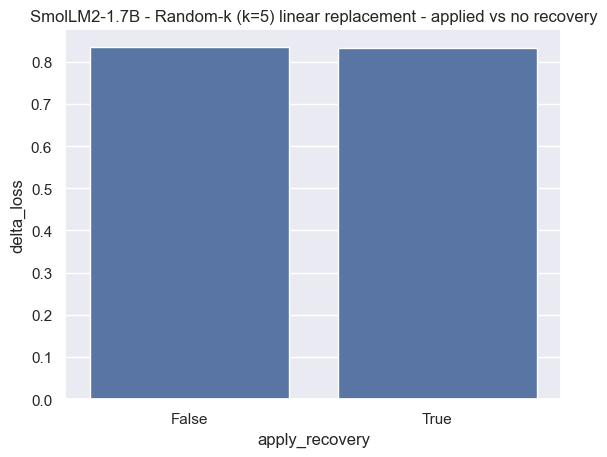

In [38]:
subset_df = run_df.query("selection_strategy == 'random_k'")

sns.barplot(subset_df, x='apply_recovery', y='delta_loss')
plt.title('SmolLM2-1.7B - Random-k (k=5) linear replacement - applied vs no recovery')

result: for linear operators the applied recovery provided no benefit

Text(0.5, 1.0, 'SmolLM2-1.7B - BI-rank based (k=5) linear replacement - applied vs no recovery')

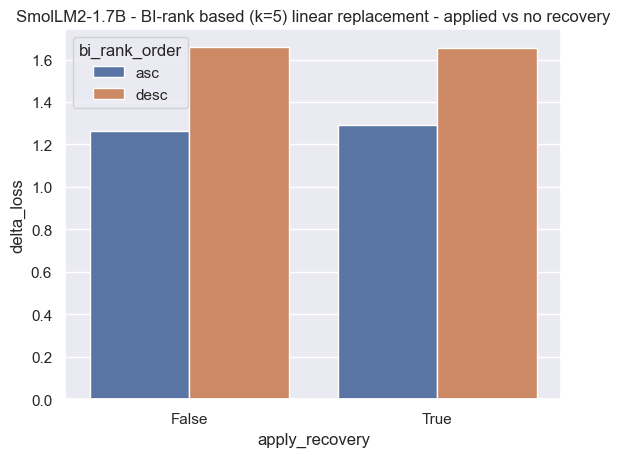

In [41]:
subset_df = run_df.query('selection_strategy == "top_k_bi"')

sns.barplot(subset_df, x='apply_recovery', y='delta_loss', hue='bi_rank_order')
plt.title('SmolLM2-1.7B - BI-rank based (k=5) linear replacement - applied vs no recovery')

result: BI rank order successfully shows that descending order of replacement (highest BI scores) when replaced produce greater loss.
BI order of replaced blocks with low BI score correctly implies lower delta loss, as these blocks represent lower vector transformation potential.

block level view:

In [43]:
block_plot_df = block_df.merge(
    run_df[["run_id", "delta_loss", "model_ppl", "ppl_ratio", "mean_block_mse", "max_block_mse"]],
    on="run_id",
    how="left"
)


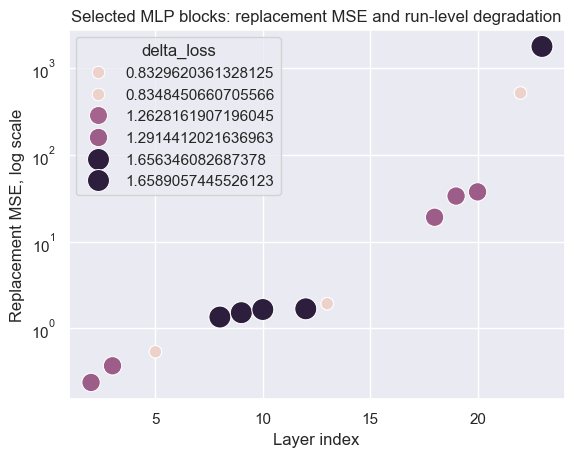

In [45]:
sns.scatterplot(
    data=block_plot_df,
    x="layer_idx",
    y="new_operator_mse",
    hue="delta_loss",
    size="delta_loss",
    sizes=(80, 250),
)

plt.yscale("log")
plt.title("Selected MLP blocks: replacement MSE and run-level degradation")
plt.xlabel("Layer index")
plt.ylabel("Replacement MSE, log scale")
plt.show()


search results

In [45]:
search_data = data["search"]["1"]["result"]

search_rows = []
search_block_rows = []

for scenario, runs in search_data.items():
    bi_order = "asc" if "_asc_" in scenario else "desc"
    apply_recovery = scenario.endswith("_recovery") and not scenario.endswith("_no_recovery")

    for run in runs:
        result = run["result"]
        logs = result["logs"]

        search_rows.append({
            "scenario": scenario,
            "bi_order": bi_order,
            "apply_recovery": apply_recovery,
            "k": run["k"],
            "target_layer_idxs": run["target_layer_idxs"],

            "base_loss": base_loss,
            "base_ppl": base_ppl,
            "model_loss": result["model_loss"],
            "model_ppl": result["model_ppl"],
            "delta_loss": result["model_loss"] - base_loss,
            "delta_ppl": result["model_ppl"] - base_ppl,
            "ppl_ratio": result["model_ppl"] / base_ppl,

            "mean_block_mse": np.mean([x["new_operator_mse"] for x in logs]),
            "max_block_mse": np.max([x["new_operator_mse"] for x in logs]),
        })

        for block_log in logs:
            search_block_rows.append({
                "scenario": scenario,
                "bi_order": bi_order,
                "apply_recovery": apply_recovery,
                "k": run["k"],
                "layer_idx": block_log["layer_idx"],
                "layer_path": block_log["layer_path"],
                "new_operator_mse": block_log["new_operator_mse"],
            })

search_df = pd.DataFrame(search_rows)
search_block_df = pd.DataFrame(search_block_rows)


In [48]:
search_df

,scenario,bi_order,apply_recovery,k,target_layer_idxs,base_loss,base_ppl,model_loss,model_ppl,delta_loss,delta_ppl,ppl_ratio,mean_block_mse,max_block_mse
0,one_shot_bi_asc_recovery,asc,True,1,[19],3.015225,20.393683,3.214536,2.489173e+01,0.199311,4.498050e+00,1.220561,33.607754,33.607754
1,one_shot_bi_asc_recovery,asc,True,2,"[18, 19]",3.015225,20.393683,3.470649,3.215759e+01,0.455423,1.176391e+01,1.576841,26.365802,33.596828
2,one_shot_bi_asc_recovery,asc,True,3,"[18, 19, 20]",3.015225,20.393683,3.876837,4.827127e+01,0.861611,2.787759e+01,2.366972,30.094008,37.549664
3,one_shot_bi_asc_recovery,asc,True,4,"[3, 18, 19, 20]",3.015225,20.393683,3.965227,5.273223e+01,0.950002,3.233855e+01,2.585714,22.665290,37.549358
4,one_shot_bi_asc_recovery,asc,True,5,"[2, 3, 18, 19, 20]",3.015225,20.393683,4.292841,7.317409e+01,1.277616,5.278041e+01,3.588076,18.176942,37.548351
5,one_shot_bi_asc_recovery,asc,True,6,"[1, 2, 3, 18, 19, 20]",3.015225,20.393683,14.155789,1.405339e+06,11.140564,1.405319e+06,68910.525021,24.150638,54.010025
6,one_shot_bi_asc_no_recovery,asc,False,1,[19],3.015225,20.393683,3.214955,2.490216e+01,0.199729,4.508479e+00,1.221072,33.598854,33.598854
7,one_shot_bi_asc_no_recovery,asc,False,2,"[18, 19]",3.015225,20.393683,3.470553,3.215452e+01,0.455328,1.176084e+01,1.576690,26.368271,33.603821
8,one_shot_bi_asc_no_recovery,asc,False,3,"[18, 19, 20]",3.015225,20.393683,3.881033,4.847425e+01,0.865808,2.808057e+01,2.376925,30.091349,37.544628
9,one_shot_bi_asc_no_recovery,asc,False,4,"[3, 18, 19, 20]",3.015225,20.393683,3.969598,5.296321e+01,0.954372,3.256953e+01,2.597040,22.660950,37.549034
